# Particle filters

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gem-epidemics/colab/blob/master/iddinf/particle_filters.ipynb)

$$
\newcommand{\yb}{\mathbf{y}}
\newcommand{\Xb}{\mathbf{X}}
\newcommand{\thetab}{\boldsymbol{\theta}}
\newcommand{\fh}{\hat{f}}
\newcommand{\wt}{\tilde{w}}
$$

## Learning outcomes
1. Learn what a state space model is.
2. Understand how particle filters work and the basic bootstrap particle filter.
3. Understand how particle filters can be used inside an MCMC algorithm (particle MCMC).
4. Use the `particles` package to implement the SIR model as a state space model and run the bootstrap PF on it.
5. Run particle MCMC on the SIR model to estimate the parameters.

## State space models
- Also known as Hidden Markov Models (HMMs)
- Consist of:
  - an unobserved Markov process $\Xb_0,\Xb_1,\dots,\Xb_t,\dots$
  - partial observations $\yb_1,\dots,\yb_t,\dots$
  - parameters $\thetab$ governing the dynamics of the Markov process

![State Space Model](../_static/images/iddinf/hmm.svg "Hidden Markov Model")

## Inference
- As previously, we are interested in estimating $\pi(\thetab|\mathbf{y})$
- To do this, we need to integrate over all possible trajectories $\mathcal{X}$ of the hidden variables $\Xb$, i.e. to calculate the **marginal likelihood**:
<!-- ## Marginal likelihood
- The **marginal likelihood** of the data given the parameters is: -->
$$
f(\mathbf{y}|\thetab)=\int_{\mathcal{X}} f(\mathbf{y}|\Xb,\thetab)f(\Xb|\thetab)d\Xb
$$
<!-- i.e. the integral over all possible trajectories of the hidden variables $\Xb\in\mathcal{X}$ -->
- This integral is typically intractable (not possible to evaluate analytically)

## Particle filtering
- Allows us to approximate the integral using a set of particles $(\Xb^{(1)},\dots,\Xb^{(M)})$:
$$
\begin{align*}
f(\yb|\thetab)&=\int_{\mathcal{X}} f(\mathbf{y}|\Xb,\thetab)f(\Xb|\thetab)d\Xb \\
&\approx\sum_{m=1}^M f(\yb|\Xb^{(m)},\thetab)=:\fh(\yb|\thetab)
\end{align*}
$$
where $\Xb^{(m)}\sim f(\Xb|\thetab)$ are simulations from the underlying model.
- $\fh(\yb|\thetab)$ is an **unbiased** estimate for $f(\yb|\thetab)$

### How particle filters work
- By repeating the following steps across observations (over time) starting from the initial values of the hidden states at time 0, $(\Xb^{(1)}_0,\dots,\Xb^{(M)}_0)$:
  1. **Propagate:** Simulate the particles forward in time $\Xb^{(m)}_{t-1}\rightarrow \Xb^{(m)}_t$.
  2. **Weight:** Weight each particle according to how well it matches the data $w^{(m)}_t$.
  3. **Resample:** Normalise the weights and resample the particles with replacement according to their normalised weights $\wt^{(m)}_t$ (this gives multiple copies of high-weight particles and no copies of low-weight particles)
- An unbiased estimate of the likelihood increment at each time step is then given by the average of the unnormalised particle weights:
$$
\fh(\yb_t|\yb_{1:t-1},\thetab)=\frac{1}{M}\sum_{m=1}^M w^{(m)}_t
$$
where $\yb_{1:t-1}=(\yb_1,\dots,\yb_{t-1})$ corresponds to the observations at times $0,\dots,t-1$
- An unbiased estimate of the overall (marginal) likelihood can then be calculated as:
$$
\begin{align*}
\fh(\yb|\thetab)&=\fh(\yb_1|\thetab)\prod_{t=2}^T \fh(\yb_t|\yb_{1:t-1},\thetab) \\
&=\prod_{t=1}^T \left(\frac{1}{M}\sum_{m=1}^M w^{(m)}_t\right)
\end{align*}
$$

### Bootstrap particle filter
- The most basic and widely used particle filter [1]
- Steps:
  1. Propagate particles by simulating from the model $\Xb^{(m)}_t\sim f(\Xb|\Xb^{(m)}_{t-1},\thetab)$
  2. Weight particles according to the likelihood $w^{(m)}_t=f(\yb_t|\Xb^{(m)}_{t},\thetab)$
  3. Normalise the weights
  $\wt^{(m)}_t=w^{(m)}_t/\sum_{m=1}^M w^{(m)}_t$ for $m=1,\dots,M$, and resample the particles according to $\wt^{(m)}_t$
- The estimate of the likelihood increment is then given by:
$$
\fh(\yb_t|\yb_{1:t-1},\thetab)=\frac{1}{M}\sum_{m=1}^M f(\yb_t|\Xb^{(m)}_t,\thetab)
$$
- The overall (marginal) likelihood estimate is given by:
$$
\fh(\yb|\thetab)=\prod_{t=1}^T \left(\frac{1}{M}\sum_{m=1}^M f(\yb_t|\Xb^{(m)}_t,\thetab)\right)
$$

## The particles package

We will use the python package particles to implement the Bootstrap Filter. This package was developed to complement the book "An Introduction to Sequential Monte Carlo" by Chopin and Papaspiliopoulos. Details of the package are available:
https://pypi.org/project/particles/

This includes documentation with examples (on which some of the following is based).

The package can be installed with "pip install particles"

In [308]:
from warnings import warn

try:
    import google.colab
    !pip install -q --no-cache-dir "numpy>=2,<2.3" particles
except:
    warn("Not running in Colab, make sure `particles` is installed locally")

First we import the package.

In [309]:
import particles
import particles.state_space_models as ssm
import particles.distributions as dists
from particles.collectors import Moments
from particles import mcmc

# standard libraries
import numpy as np
from matplotlib import pyplot as plt

# Compatibility for older versions of particles
np.float = float
np.int = int

## Defining the SIR Model as a State Space Model

Particles works through specifying a State Space Model, and then has various functions for simulating from the model or for running the Bootstrap (or other) filters.

To define a State Space Model we need to define the initial distribution; the transition density and the likelihood.
These are defined in terms of functions in dists, see
https://particles-sequential-monte-carlo-in-python.readthedocs.io/en/latest/distributions.html#module-particles.distributions

The state will be $X_t=(S_t,I_t)$. The model will have four parameters:
* ```N``` -- the population size = $S_0+I_0$
* ```I0``` -- the initial number of infectives
* ```beta``` -- the scaled infection rate per pair, so infection of one susceptible at rate $\beta I_t/N$
* ```gamma``` -- the recovery rate
* ```p``` -- the parameter of the likelihood model (we use a Poisson model; a Binomial model appears to give numerical issues, perhaps due to how ```particles``` calculates the log-likelihod for the Binomial when the likelihood is 0).

Here we want to try a model where we observe a fixed proportion $p$ of the $S$ to $I$ transitions.

We will augment the state to include the number of transitions from $S$ to $I$ and from $I$ to $R$. This is needed due to how the ```particles``` package constructs (non-standard) multivariate distributions.

In [338]:
class SIR(ssm.StateSpaceModel):
    default_params = {'N': 100, 'I0': 5, 'beta': 0.8, 'gamma': 0.4, 'p': 1.0}  # optional

    def PX0(self):  # Distribution of X_0 =(Z_SI,Z_IR,S,I) the first two entries are place holders
        ## ordering matters due to conditional simulation in PX
        prior = dists.StructDist(
            dists.OrderedDict({
                'Z_SI': dists.Dirac(0),
                'Z_IR': dists.Dirac(0),
                'S': dists.Dirac(self.N - self.I0),
                'I': dists.Dirac(self.I0)
            })
        )
        return prior

    def PX(self, t, xp):  # Distribution of X_t given X_{t-1}
        S = int(xp['S'][0])
        I = int(xp['I'][0])

        # Ensure non-negative integers
        if S < 0:
            S = 0
        if I < 0:
            I = 0

        # infection probability
        p_inf = 1.0 - np.exp(-self.beta * xp['I'] / self.N)
        p_inf = np.clip(p_inf, 0, 1)  # Clip values to be within [0, 1]

        # we simulate the number transitions from S to I (ZtoI) and I to R (ZtoR) and then
        # the new states are defined as Dirac (i.e. deterministic) distributions condtional on these.
        chain = dists.StructDist(
            dists.OrderedDict({
             'Z_SI': dists.Binomial(n=S, p=p_inf),
             'Z_IR': dists.Binomial(n=I, p=1.0-np.exp(-self.gamma)),
             'S': dists.Cond(lambda x: dists.Dirac(S - x['Z_SI'])),
             'I': dists.Cond(lambda x: dists.Dirac(I + x['Z_SI'] - x['Z_IR']))
            })
        )
        return chain

    def PY(self, t, xp, x):  # Distribution of Y_t given X_t (and X_{t-1})
        return dists.Poisson(x['Z_SI'] * self.p)

Now we can instantiate the SIR SSM and simulate some data using the `.simulate()` method from our `SIR()` class

In [339]:
np.random.seed(123)
SIRssm = SIR()
SIR_true_states, SIR_data = SIRssm.simulate(20)
print(SIR_true_states)

[array([(0., 0., 95., 5.)],
      dtype=[('Z_SI', '<f8'), ('Z_IR', '<f8'), ('S', '<f8'), ('I', '<f8')]), array([(5, 1, 90., 9.)],
      dtype=[('Z_SI', '<i8'), ('Z_IR', '<i8'), ('S', '<f8'), ('I', '<f8')]), array([(4, 3, 86., 10.)],
      dtype=[('Z_SI', '<i8'), ('Z_IR', '<i8'), ('S', '<f8'), ('I', '<f8')]), array([(8, 3, 78., 15.)],
      dtype=[('Z_SI', '<i8'), ('Z_IR', '<i8'), ('S', '<f8'), ('I', '<f8')]), array([(15, 6, 63., 24.)],
      dtype=[('Z_SI', '<i8'), ('Z_IR', '<i8'), ('S', '<f8'), ('I', '<f8')]), array([(11, 7, 52., 28.)],
      dtype=[('Z_SI', '<i8'), ('Z_IR', '<i8'), ('S', '<f8'), ('I', '<f8')]), array([(9, 11, 43., 26.)],
      dtype=[('Z_SI', '<i8'), ('Z_IR', '<i8'), ('S', '<f8'), ('I', '<f8')]), array([(8, 5, 35., 29.)],
      dtype=[('Z_SI', '<i8'), ('Z_IR', '<i8'), ('S', '<f8'), ('I', '<f8')]), array([(7, 11, 28., 25.)],
      dtype=[('Z_SI', '<i8'), ('Z_IR', '<i8'), ('S', '<f8'), ('I', '<f8')]), array([(3, 6, 25., 22.)],
      dtype=[('Z_SI', '<i8'), ('Z_IR', '<i

Plot the data

Text(0, 0.5, 'New infections')

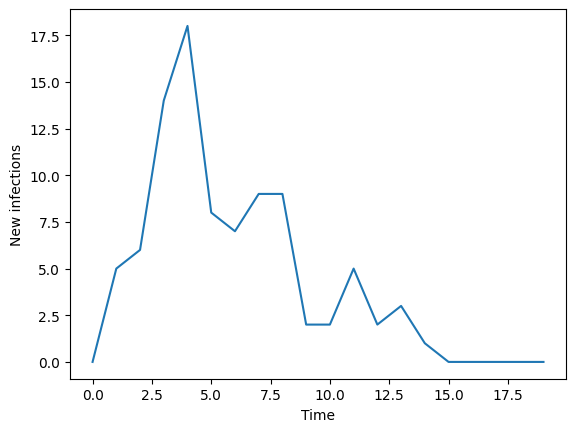

In [340]:
plt.plot(SIR_data)
plt.xlabel("Time")
plt.ylabel("New infections")

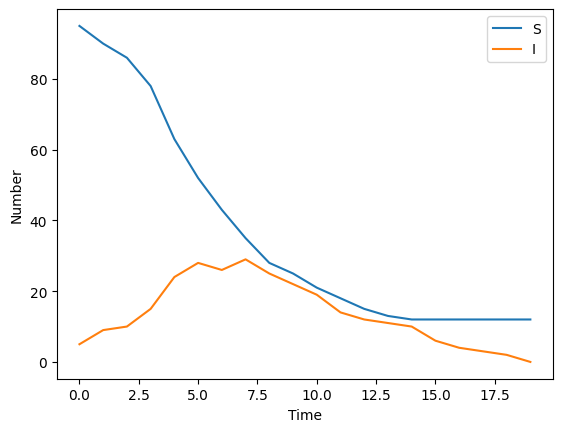

In [313]:
plt.plot([x['S'] for x in SIR_true_states], label="S")
plt.plot([x['I'] for x in SIR_true_states], label="I")
plt.xlabel("Time")
plt.ylabel("Number")
plt.legend()

We will now try out the bootstrap filter on this model



In [314]:
def build_SIR(beta,gamma):
    return SIR(
        N=100,        # fixed
        I0=5,         # fixed
        p=1.0,        # fixed
        beta=beta,   # estimated
        gamma=gamma  # estimated
    )

In [315]:
def build_bootstrap(beta, gamma, data):
  return ssm.Bootstrap(ssm=build_SIR(beta, gamma), data=data)

We can look at how the bootstrap filter works by running it one timestep at a time and plotting the particle trajectories. Repeat running the last of the three blocks of code below to see the filter in action: particles being repeatedly propagated between observations, weighted, and resampled. *Tip: scroll towards the bottom of the code block so that you can press the play button for Run cell while viewing the plot.*

In [316]:
fk_model_SIR = build_bootstrap(beta=0.8, gamma=0.4, data=SIR_data)  # we use the Bootstrap filter
bf = particles.SMC(fk=fk_model_SIR, N=5, resampling='residual', ESSrmin=1.0)  # the algorithm

In [317]:
np.random.seed(1234)
t = 0

next(bf)
print(bf.X['Z_SI'])
print(bf.W)
print(bf.A)
t = t + 1

Z_SI = bf.X['Z_SI'].copy()

proposed_history = []
weights_history = []
times = []
proposed = []

[0. 0. 0. 0. 0.]
[0.2 0.2 0.2 0.2 0.2]
None


[2 4 3 5 5]
[0.05602759 0.2426403  0.1565178  0.27240716 0.27240716]
[0 1 2 3 4]


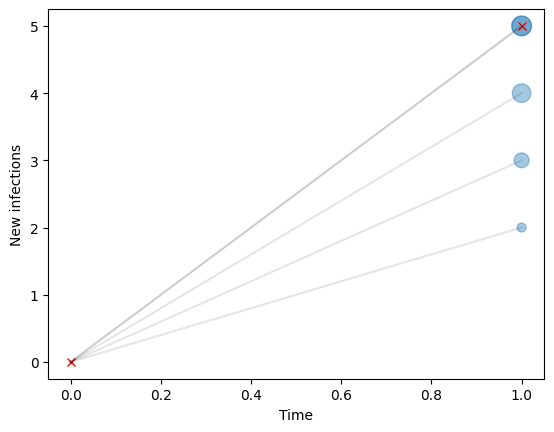

In [318]:
if t < 20:
  proposed_history.append(Z_SI.copy())

  next(bf)

  Z_new = bf.X['Z_SI']
  W = bf.W

  print(Z_new)
  print(W)
  print(bf.A)

  if not np.all(np.isfinite(W)):
        raise RuntimeError(
            f"Particle filter failed at t={t}: "
            f"weights contain NaN/Inf.\n"
            f"Weights: {W}"
        )

  weights_history.append(bf.W)
  times.append(np.full(bf.N, t))
  proposed.append(Z_new)

  # Get the ancestral paths
  if Z_SI.ndim == 1:
    Z_SI = Z_SI[bf.A]
  else:
    Z_SI = Z_SI[:,bf.A]

  # Add the simulations up to the new observation
  Z_SI = np.vstack([Z_SI, Z_new])

  # Marker sizes based on weights
  sizes = [200 * w/w.max() for w in weights_history]

  # Plot the proposed and filtered paths
  plt.plot(SIR_data[:t+1],'rx')
  for paths in proposed_history[1:]:
    plt.plot(paths, 'k-', alpha=0.05)
  plt.scatter(np.vstack(times), np.vstack(proposed), s=np.vstack(sizes), alpha=0.4)
  plt.plot(Z_SI, 'k-', alpha=0.1)
  plt.xlabel("Time")
  plt.ylabel("New infections")

  t = t + 1

We can also make a function to run the filter over the entire time series and return one of the filtered trajectories using the `.run()` method for the `bf` filter object:

In [319]:
def run_filter(beta, gamma, data):
  fk_model_SIR = build_bootstrap(beta, gamma, data)  # we use the Bootstrap filter
  # bootstrap filter
  bf = particles.SMC(fk=fk_model_SIR, N=1000, resampling='residual',
                     ESSrmin=1.0, store_history=True)  # the algorithm

  # run particle filter
  bf.run()

  return bf.hist.extract_one_trajectory()

Run the filter and plot the filtered trajectory against the data

In [320]:
traj = run_filter(beta=0.8, gamma=0.4, data=SIR_data)

In [321]:
S = np.array([x['S'] for x in traj])
I = np.array([x['I'] for x in traj])
Z_SI = np.array([x['Z_SI'] for x in traj])
Z_IR = np.array([x['Z_IR'] for x in traj])

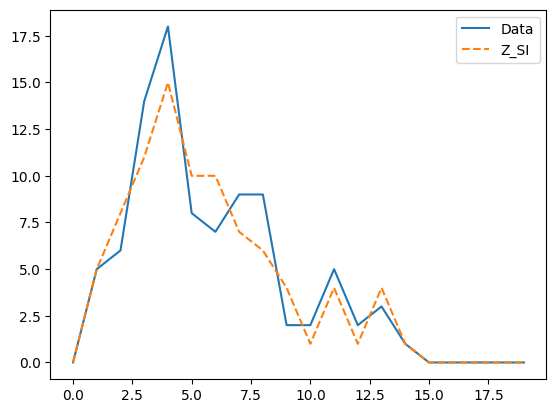

In [322]:
plt.plot(SIR_data, label="Data")
plt.plot([1.0*x for x in Z_SI], '--', label="Z_SI")
# plt.plot(Z_IR, label="Z_IR")
plt.legend()

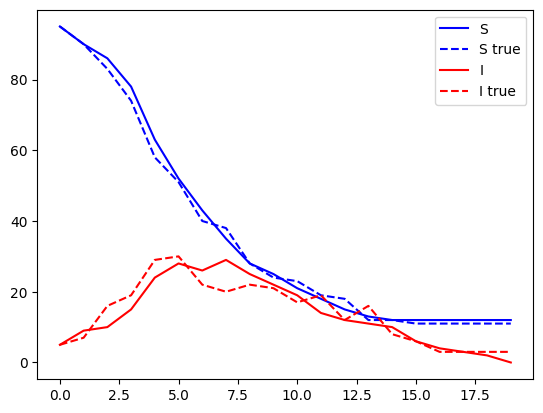

In [323]:
plt.plot([x['S'] for x in SIR_true_states], 'b', label="S")
plt.plot(S, 'b--', label="S true")
plt.plot([x['I'] for x in SIR_true_states], 'r', label="I")
plt.plot(I, 'r--', label="I true")
plt.legend()

````{exercise}
:label: ex 14.1

Modify the code for the SIR model above so that the exact number of new infections are observed, resimulate the data and run the particle filter step by step as before. What do you observe?

Try increasing the number of particles. What do you observe now? *Tip: You'll want to comment out the printing of the state values, weights, and ancestor indices.*

````

````{solution} ex 14.1
:class: dropdown

You should set `PY` to
```
def PY(self, t, xp, x):  # Distribution of Y_t given X_t (and X_{t-1})
        return dists.Dirac(x['Z_SI'])
```
in the definition of the `SIR()` class above to get exact observations.

With exact observations and 5 particles, you will see that eventually the particle filter collapses – all the particles miss the observed data and get zero weight. This is an extreme example of a phenomenon known as **particle degeneracy** – where most of the weight becomes concentrated on a small number of particles after a number of steps of the filter, leading to a poor approximation of the posterior distribution of the state, and poor mixing of PMMH.

Increasing the number of particles, e.g. to 1000, stops the particle filter collapsing.

In general, the tighter the observation distribution, the more particles are required to deal with particle degeneracy.
````

## Pseudo-marginal MCMC
- **Key idea**: There is a remarkable result that says that if you replace the likelihood $f(\yb|\thetab)$ in a standard MCMC algorithm with a non-negative and unbiased estimate of the likelihood $\fh(\yb|\thetab)$, then it will still converge to the true posterior
- Known as **pseudo-marginal MCMC** [2,3]
- The acceptance probability becomes
$$
\alpha = \min\left(1,\frac{\fh(\yb|\thetab')f(\thetab')}{\fh(\yb|\thetab^{(i)})f(\thetab^{(i)})}\frac{q(\thetab^{(i)}|\theta')}{q(\thetab'|\thetab^{(i)})}\right)
$$

## Particle MCMC
- Pseudo-marginal MCMC leads on to the idea of particle MCMC [4] – using a particle filter to get an unbiased estimate of the likelihood that can be plugged into a standard MCMC algorithm.
- We will look at putting a particle filter into the Metropolis-Hastings algorithm to get what is known as the Particle Marginal Metropolis-Hastings (PMMH) algorithm.
- We will use PMMH to estimate the parameters of the SIR model from the data we simulated from our `particles` state space model.

First we pick some priors for our parameters $\beta$ and $\gamma$. Here, we have picked $\mathrm{Gamma}(1,1)\equiv\mathrm{Exp}(1)$ priors for both.

In [324]:
prior = dists.StructDist({
    'beta': dists.Gamma(a=1.0, b=1.0),   # positive scale parameter
    'gamma': dists.Gamma(a=1.0, b=1.0)
})

Run PMMH on the simulated data

In [341]:
# PMMH algorithm
theta0 = prior.rvs(size=1)
theta0['beta'] = 0.8
theta0['gamma'] = 0.4

pmcmc = mcmc.PMMH(
    niter=2000,          # number of MCMC iterations
    ssm_cls=build_SIR,
    prior=prior,
    data=SIR_data,
    Nx=1000,             # number of SMC particles
    fk_cls=ssm.Bootstrap#,
    # theta0=theta0      # starting values (o/w drawn from prior)
)

# Run the PMCMC sampler
np.random.seed(1234)
pmcmc.run()

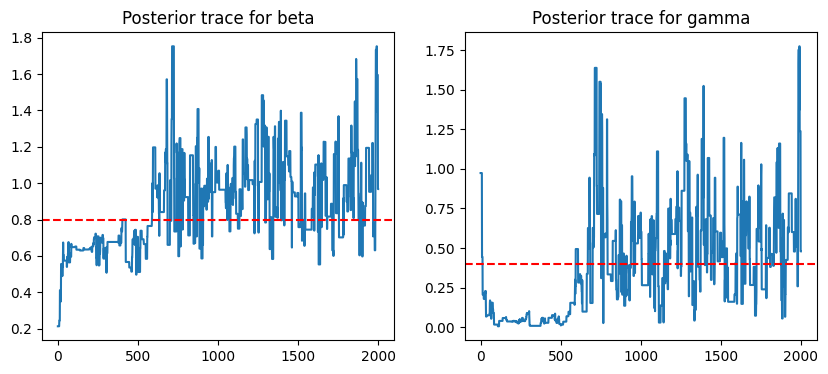

In [342]:
theta_samples = pmcmc.chain.theta  # list of dictionaries

betas = np.array([th['beta'] for th in theta_samples])
gammas = np.array([th['gamma'] for th in theta_samples])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(betas)
plt.axhline(0.8, color='r', linestyle='--')
plt.title("Posterior trace for beta")

plt.subplot(1,2,2)
plt.plot(gammas)
plt.axhline(0.4, color='r', linestyle='--')
plt.title("Posterior trace for gamma")

plt.show()

In [343]:
Z_SI_post = []

for i in range(0, betas.shape[0], 10): # thin to every 10th sample
  traj = run_filter(betas[i], gammas[i], SIR_data)

  Z_SI_post.append([x['Z_SI'] for x in traj])

Plot the posterior sample trajectories

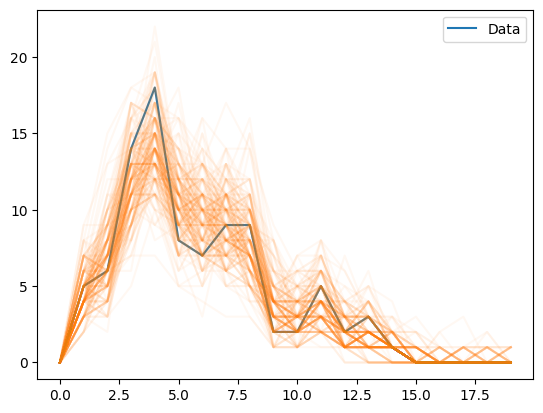

In [344]:
plt.plot(SIR_data, label="Data")

for i in range(len(Z_SI_post)):
  Z_SI_post_scld = [x * 1.0 for x in Z_SI_post[i]]
  plt.plot(Z_SI_post_scld, color="C1", alpha=0.05)

plt.legend()

````{exercise}
:label: ex14.2

Run PMMH on the simulated data with exact observations. What do you observe?

Try changing the random number seed to `123`, or setting the starting values of `beta` and `gamma` to their true values, and rerunning the MCMC. What happens? Why do you think this is?
````

````{solution} ex 14.2
:class: dropdown

The parameters stay stuck as there are no acceptances. The starting values are far from the true values, so the particle filter eventually collapses (all the particles miss the observed data and get zero weight).

Changing the random number seed (or starting the parameters at their true values) gives starting values near (or at) the true values, so the particle filter no longer collapses (some of the particles hit the observed data points and get non-zero weights).

````

## Further exercises

````{exercise}
:label: ex14.3

Try modifying the code above for the SIR model to define the SEIR model as a state space model, simulate data from it, and run PMMH on the simulated data to estimate the model parameters.
````

````{exercise}
:label: ex14.4

Try alternative likelihood models, such as negative binomial observations of the number of new infections or binomial observations of the number of infected individuals, and see how this affects inference of the hidden states and parameters.

````

## References

1. Gordon, N.J.; Salmond, D.J.; Smith, A.F.M. (1993). "Novel approach to nonlinear/non-Gaussian Bayesian state estimation". IEE Proceedings F - Radar and Signal Processing. 140 (2): 107–113. [doi:10.1049/ip-f-2.1993.0015](https://doi.org/10.1049/ip-f-2.1993.0015)
2. Beaumont, Mark A. (2003). “Estimation of population growth and decline in genetically monitored populations”. In: Genetics 164,
pp. 1139–1160. [doi:10.1093/genetics/164.3.1139](https://doi.org/10.1093/genetics/164.3.1139)
3. Andrieu, Christophe and Gareth O. Roberts (2009). “The pseudo-marginal approach for efficient Monte Carlo simulation”. In: The
Annals of Statistics 37.2, pp. 697–725. [doi:10.1214/07-aos574](https://doi.org/10.1214/07-aos574)
4. Andrieu, Christophe et al. (2010). “Particle Markov chain Monte Carlo methods”. In: Journal of the Royal Statistical Society, Series
B (Methodological) 72.3, pp. 269–342. [doi:10.1111/j.1467-9868.2009.00736.x](https://doi.org/10.1111/j.1467-9868.2009.00736.x)

## Further reading
- [Endo A, van Leeuwen E, Baguelin M (2019). Introduction to particle Markov-chain Monte Carlo for disease dynamics modellers. Epidemics 29:100363.](https://doi.org/10.1016/j.epidem.2019.100363)
- [T.J. McKinley (2026). Introduction to Particle MCMC.](https://tjmckinley.github.io/IDDConfWorkshop/PMCMCSLIDES.pdf)
- [Darren Wilkinson's blog](https://darrenjw.wordpress.com/2011/12/30/catalogue-of-my-first-25-blog-posts/)
<!-- - MFIIDD notes? -->
- [Paul Fearnhead (2024). An Introduction to Particle Filters](particle-filters-1.pdf)
- [MCMC for State Space Models, Handbook of MCMC](https://arxiv.org/pdf/2510.04932)